In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from smooth_POD_ROM.post_processing import richardson_lucy, post_process

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.5

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 100

8.030570172000001


In [3]:
def plot_setup0():
    fig, ax = plt.subplots(figsize=(page_width_in/3, page_width_in/4))
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticklabels([])
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    
    plt.xlabel("x")
    plt.xlim(-0.01, 1.01)
    plt.ylim(-0.1, 1.1)
    return fig, ax
# def plot_setup():
#     fig, axs = plt.subplots(3, 2, figsize=(page_width_in, page_width_in/2))
#     for ax in axs
#         ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
#         ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
#         ax.set_yticklabels([])
#     plt.grid(True, which='minor', linestyle='--', lw=.25)
#     plt.grid(True, which='major', linestyle='-')
    
#     plt.xlabel("x")
#     plt.xlim(-0.01, 1.01)
#     plt.ylim(-0.1, 1.1)
#     return fig, axs

In [4]:
def approximate(A, N3):
    coefficients, _, _, _ = np.linalg.lstsq(A, N3, rcond=None)
    return np.sum(A*coefficients, axis=-1)

In [5]:
m = 1000
x = np.linspace(0, 1, m)

def f1(x, mu, w=0.1):
    # original
    y = np.zeros_like(x)
    y[np.abs(x-mu)<(w+1e-6)] = 1
    return y


def f2(x, mu):
    # moving averagee
    y = f1(x, mu)
    k = np.ones((250,))/250
    return np.convolve(y, k, mode='same')


def f3(x, mu, w=0.1, s=0.15):
    # gaussian smoothing
    y = f1(x, mu, w)
    dx = 1/m
    y2 = gaussian_filter1d(y, sigma=s/dx)
    return y2




In [6]:
n_e = np.array([[1, 0.9915602777347968, 0.9713204529128298, 1.0001674032218772],
[2, 0.9800439892665738, 0.9426793537319377, 1.0010495175479033],
[3, 0.9729772574384362, 0.9147886762130124, 0.9990377222037792],
[4, 0.9637453242763269, 0.8926941711718424, 0.997572774094741],
[5, 0.9546007954403496, 0.8634061605637575, 0.9566961679632406],
[6, 0.9389027076392107, 0.8348038935401098, 0.9663541860295661],
[7, 0.9410160728536333, 0.8082931770712304, 0.9549020734428649],
[8, 0.9288725846785706, 0.7983255217784782, 0.9269955839926713],
[9, 0.9193712940585046, 0.7765037086613361, 0.8980300722075967],
[10, 0.9032442997672238, 0.7472370712375711, 0.9033691531717912],
[11, 0.896635576405151, 0.7069576675322532, 0.8693594380174251],
[12, 0.897206871960043, 0.7003214543861801, 0.8803431636043461],
[13, 0.8852251060560975, 0.6724498443125627, 0.8466112005645655],
[14, 0.8653343219105747, 0.6513544614791253, 0.7943034463271046],
[15, 0.8709266683364522, 0.6185995956661724, 0.7947075405437432],
[16, 0.8564038247147076, 0.5886068468798729, 0.7363566783402634],
[17, 0.856546286566038, 0.5857704728548139, 0.7385737238051788],
[18, 0.8290618093666203, 0.5357962649222289, 0.7254447114077713],
[19, 0.8348216492704089, 0.5445584898042151, 0.6782415782542819],
[20, 0.8366456494829377, 0.5275284476895556, 0.6395038537538109],
[21, 0.8138297549320097, 0.4826585209176945, 0.6366282285696527],
[22, 0.8118358309363626, 0.48529399239976917, 0.6342183453193039],
[23, 0.8014072527196859, 0.4531985494475518, 0.6097070615452986],
[24, 0.7917715529844445, 0.4556437385955459, 0.5978533209244328],
[25, 0.7940605332928902, 0.4410195508059842, 0.5979447479379131],
[26, 0.783746743675046, 0.42568091813711656, 0.5542158544722154],
[27, 0.7649337273651232, 0.37642009927881054, 0.4572502607023034],
[28, 0.7584373354148914, 0.4030440673787413, 0.5410494500692345],
[29, 0.7779387758583538, 0.3727804635366, 0.4872423187264322],
[30, 0.7542480111021365, 0.3628206699250984, 0.4656196857343717],
[31, 0.7425218772366591, 0.3515970567662122, 0.45157916213423854],
[32, 0.7233938482412554, 0.3040121609675814, 0.4297648340185679],
[33, 0.7389430377174562, 0.3367568701196455, 0.4312560989874027],
[34, 0.7172130527819874, 0.29945769877103917, 0.3872798788482367],
[35, 0.70822685085754, 0.3127279301849399, 0.4160751980637806],
[36, 0.711845406570528, 0.2804622125560813, 0.3567234710906892],
[37, 0.6993074547197768, 0.24770108609654937, 0.35377423191261625],
[38, 0.7077052566119425, 0.290028273633097, 0.3748238176376257],
[39, 0.6957431702673702, 0.2548100480256682, 0.3381345557989326],
[40, 0.6821242073305832, 0.23138586886531706, 0.311801948137881],
[41, 0.6703489506993581, 0.20887929480724338, 0.3016684344367604],
[42, 0.686505772185688, 0.2022486757405843, 0.27468562421098247],
[43, 0.6672272075291057, 0.23216872267766733, 0.2903078526028994],
[44, 0.6555622175341566, 0.16615680082340908, 0.23175767583606038],
[45, 0.6437975960299089, 0.17916036259199014, 0.23656099060462948],
[46, 0.6484093609890108, 0.19581127190446912, 0.30135537155570863],
[47, 0.642843599808815, 0.15583727007835066, 0.232963997477575],
[48, 0.6400155227994281, 0.16359333285194083, 0.21702621388501186],
[49, 0.6401554397412752, 0.16187068388834772, 0.2242954683947579],
[50, 0.6600003818012723, 0.15668210577581462, 0.21398481338279465],
[51, 0.6255996001572653, 0.12768857117526508, 0.17042772474037984],
[52, 0.6368171168363657, 0.15613076633969894, 0.22388618161129628],
[53, 0.6082591492379366, 0.11638262448610744, 0.16952375027608646],
[54, 0.6028516518752629, 0.11437759528365297, 0.16486748565626774],
[55, 0.6006609541276757, 0.12191001033908498, 0.16420855062370077],
[56, 0.5879661275625865, 0.10300412138926181, 0.156170734422684],
[57, 0.6157881012394104, 0.10324208640346275, 0.14521201093401653],
[58, 0.5956145373280265, 0.09188607517564602, 0.13338301642602357],
[59, 0.5611084077310503, 0.11148341842014035, 0.17237844616559875],
[60, 0.5872274356967052, 0.09881174042544667, 0.14182943478373608],
[61, 0.5882579552441006, 0.0920551596963125, 0.15629859075510152],
[62, 0.5742144029034127, 0.05446585798521665, 0.10743125604592563],
[63, 0.5700774637810928, 0.075124819507643, 0.12889075974906108],
[64, 0.5671405407885198, 0.08545369018520305, 0.1279042785640802],
[65, 0.5464599040924977, 0.07163384007039562, 0.1299635296807168],
[66, 0.5613509593103059, 0.07332109841214694, 0.12225345098203015],
[67, 0.5389727361987816, 0.05938457309832631, 0.10664091738323828],
[68, 0.5223580487800707, 0.05077325452022851, 0.09128176667206502],
[69, 0.5394154325770879, 0.0506823248201001, 0.10331724740812236],
[70, 0.5550930521429294, 0.06849435685986408, 0.11821010962825407],
[71, 0.5330362006765249, 0.031138994322249414, 0.08301058889922615],
[72, 0.5208115336452662, 0.028368816128440593, 0.07686616903126793],
[73, 0.5023701238817317, 0.03120312546223689, 0.07544806629046219],
[74, 0.5043561412672161, 0.03943860727576613, 0.09211662532041566],
[75, 0.5053558303336034, 0.028883080829873616, 0.07463478425664734],
[76, 0.4951177664228687, 0.04537658161184115, 0.09843886054249969],
[77, 0.5309838751908884, 0.049576410722694725, 0.10196695010022447],
[78, 0.4994659405602328, 0.024519696056535225, 0.07790711283682655],
[79, 0.4976506478334496, 0.018123237247721188, 0.0682902983097661],
[80, 0.4685919198595201, 0.022763260025366914, 0.07533980934572697],
[81, 0.4846252306298366, 0.03370667157860804, 0.09315522552475745],
[82, 0.4911903203388439, 0.014814149222901897, 0.06690299268021255],
[83, 0.48467565681760266, 0.024623618156363904, 0.07433098379382005],
[84, 0.4727109441865622, 0.021667909126448167, 0.07637358817276414],
[85, 0.460737520109132, 0.008383731858879561, 0.06563231275983748],
[86, 0.47649144704961705, 0.021800003307351178, 0.07761197090549757],
[87, 0.46890382410158526, 0.012167129752295164, 0.06793524116846154],
[88, 0.4728485048988434, 0.020090289603433495, 0.07352474474243341],
[89, 0.4532829991113038, 0.018344948195073842, 0.07815275716049473],
[90, 0.4657503274827503, 0.012005662255580975, 0.06890614225531293],
[91, 0.4824472976720308, 0.012476184579132577, 0.06992975598092603],
[92, 0.4732426819786568, 0.009377635742922897, 0.06996311861164242],
[93, 0.46684945531929517, 0.013652531072873349, 0.07042779269962823],
[94, 0.4416774956813337, 0.008097699602039878, 0.06537923476362935],
[95, 0.414714618342568, 0.002146886429312457, 0.0670689091663222],
[96, 0.4462032742122175, 0.013841625574913502, 0.06747356532989138],
[97, 0.4397363587446656, 0.008948843910323044, 0.06692751099931851],
[98, 0.44675699775088773, 0.006137896166745248, 0.06715130275682786],
[99, 0.4218803828088678, 0.001717332383528688, 0.06558232341220378]])

(<Figure size 1618.7x809.35 with 13 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

C:\Users\florianma\Anaconda3\lib\site-packages\IPython\core\events.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
C:\Users\florianma\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


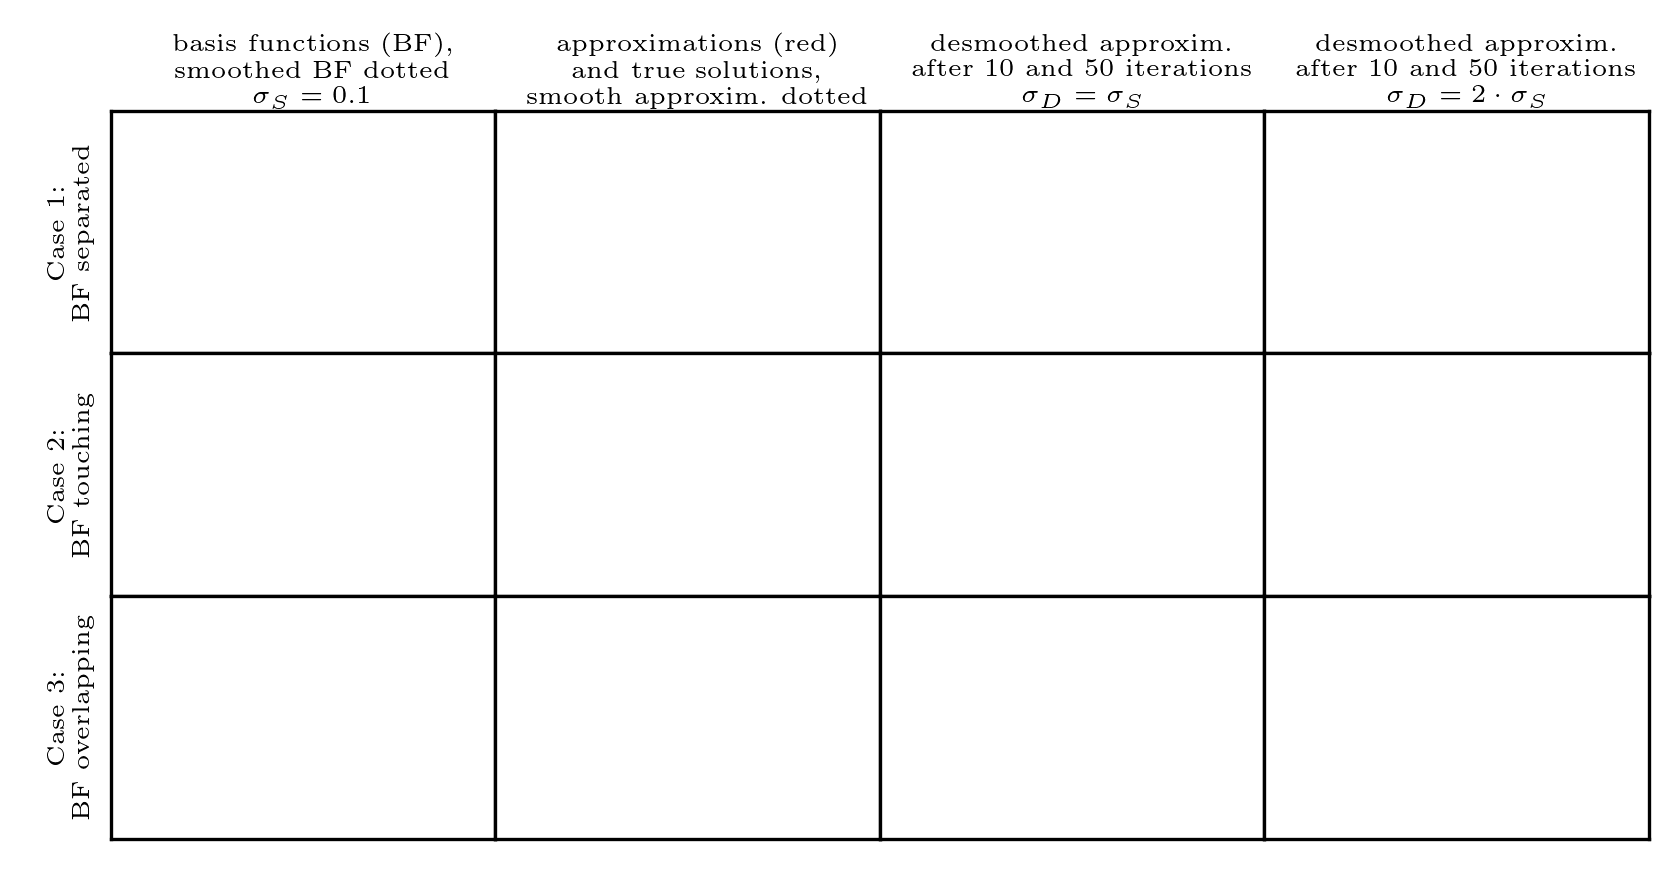

In [7]:

def small_figures():
    fig = plt.figure(figsize=(page_width_in, page_width_in/2))
    ax0 = fig.add_axes([0, 0, 1, 1])
    ax0.axis('off')
#     ax0.set_xticks([])
#     ax0.set_yticks([])
#     plt.text(0, 0, "0, 0")
#     plt.text(0, 1, "0, 1")
#     plt.text(1, 0, "1, 0")
#     plt.text(1, 1, "1, 1")
    
    spacingw = 0.05
    spacingh = 0.1
    w = 1/4-spacingw/4
    h = 1/3-spacingh/3
    
    l1, l2, l3, l4 = 0+spacingw, 1/4+3/4*spacingw, 2/4+2/4*spacingw, 3/4+1/4*spacingw
    b1, b2, b3 = 0, 1/3-spacingh*1/3, 2/3-spacingh*2/3
    
    ax00 = fig.add_axes([l1, b3, w, h])  # [left,bottom,width,height]
    ax01 = fig.add_axes([l2, b3, w, h])
    ax02 = fig.add_axes([l3, b3, w, h])
    ax03 = fig.add_axes([l4, b3, w, h])
    
    ax10 = fig.add_axes([l1, b2, w, h])
    ax11 = fig.add_axes([l2, b2, w, h])
    ax12 = fig.add_axes([l3, b2, w, h])
    ax13 = fig.add_axes([l4, b2, w, h])
    
    ax20 = fig.add_axes([l1, b1, w, h])
    ax21 = fig.add_axes([l2, b1, w, h])
    ax22 = fig.add_axes([l3, b1, w, h])
    ax23 = fig.add_axes([l4, b1, w, h])
    
    axs = np.array([[ax00, ax01, ax02, ax03],
                    [ax10, ax11, ax12, ax13],
                    [ax20, ax21, ax22, ax23]])
    
    for ax_row in axs:
        for ax  in ax_row:
            ax.set_xticks(np.linspace(-1, 1, 5, endpoint=True), minor=False)
            ax.set_yticks(np.linspace(-1, 1, 5, endpoint=True), minor=False)
            ax.set_xticks(np.linspace(-1, 1, 21, endpoint=True), minor=True)
            ax.set_yticks(np.linspace(-1, 1, 21, endpoint=True), minor=True)
            #ax.tick_params(left=False, bottom=False) 
            #ax.set_xticklabels([])
            #ax.set_yticklabels([])
            #ax.grid(True, which='minor', linestyle='--', lw=.25)
            #ax.grid(True, which='major', linestyle='-')
            for ticks in [ax.xaxis.get_major_ticks(), ax.xaxis.get_minor_ticks(), ax.yaxis.get_major_ticks(), ax.yaxis.get_minor_ticks()]:
                for tick in ticks:
                    tick.tick1line.set_visible(False)
                    tick.tick2line.set_visible(False)
                    tick.label1.set_visible(False)
                    tick.label2.set_visible(False)
            ax.set_xlim(-0.01, 1.01)
            ax.set_ylim(-0.1, 1.1)
    fontdict = {"ha": "center", "va":"center", "rotation": 0, "fontsize":6}
    ax0.text(1/8+spacingw, b3+h+spacingh/2, "basis functions (BF),\nsmoothed BF dotted\n$\sigma_S=0.1$", fontdict=fontdict)
    ax0.text(3/8+spacingw/4*3, b3+h+spacingh/2, "approximations (red)\nand true solutions,\nsmooth approxim. dotted", fontdict=fontdict)
    ax0.text(5/8+spacingw/4*2, b3+h+spacingh/2, "desmoothed approxim.\nafter 10 and 50 iterations\n$\sigma_D=\sigma_S$", fontdict=fontdict)
    ax0.text(7/8+spacingw/4*1, b3+h+spacingh/2, "desmoothed approxim.\nafter 10 and 50 iterations\n$\sigma_D=2\cdot\sigma_S$", fontdict=fontdict)
    
    fontdict["rotation"] = 90
    ax0.text(spacingw/2, h*5/2, "Case 1:\nBF separated", fontdict=fontdict)
    ax0.text(spacingw/2, h*3/2, "Case 2:\nBF touching", fontdict=fontdict)
    ax0.text(spacingw/2, h/2, "Case 3:\nBF overlapping", fontdict=fontdict)
#     ax0.text(1/3, 5/6, "smoothing", fontdict={"ha": "center", "va":"center", "rotation":0, "fontsize":6})
#     ax0.text(1/6, 4/6, "linear\napproximation", fontdict={"ha": "center", "va":"center", "rotation":"horizontal", "fontsize":6})
#     ax0.text(3/6, 4/6, "linear\napproximation", fontdict={"ha": "center", "va":"center", "rotation":"horizontal", "fontsize":6})
#     ax0.text(4/6, 4/6, "desmoothing", fontdict={"ha": "center", "va":"center", "rotation": 45, "fontsize":6})
#     ax0.text(4/6, 3/6, "desmoothing", fontdict={"ha": "center", "va":"center", "rotation": 0, "fontsize":6})
#     ax0.text(5/6, 2/6, "optimization", fontdict={"ha": "center", "va":"center", "rotation": 0, "fontsize":6})
    return fig, axs

small_figures()

\\files.ad.ife.no\MatPro_files\Florian\Repositoties\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:24: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


0.418 &0.359 &0.398 &0.454 &0.242 &0.126 &\\
0.316 &0.291 &0.257 &0.296 &0.156 &0.086 &\\
0.274 &0.264 &0.195 &0.209 &0.141 &0.072 &\\


C:\Users\florianma\AppData\Local\Temp\ipykernel_16656\3132863659.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(pth+"example1.pdf")


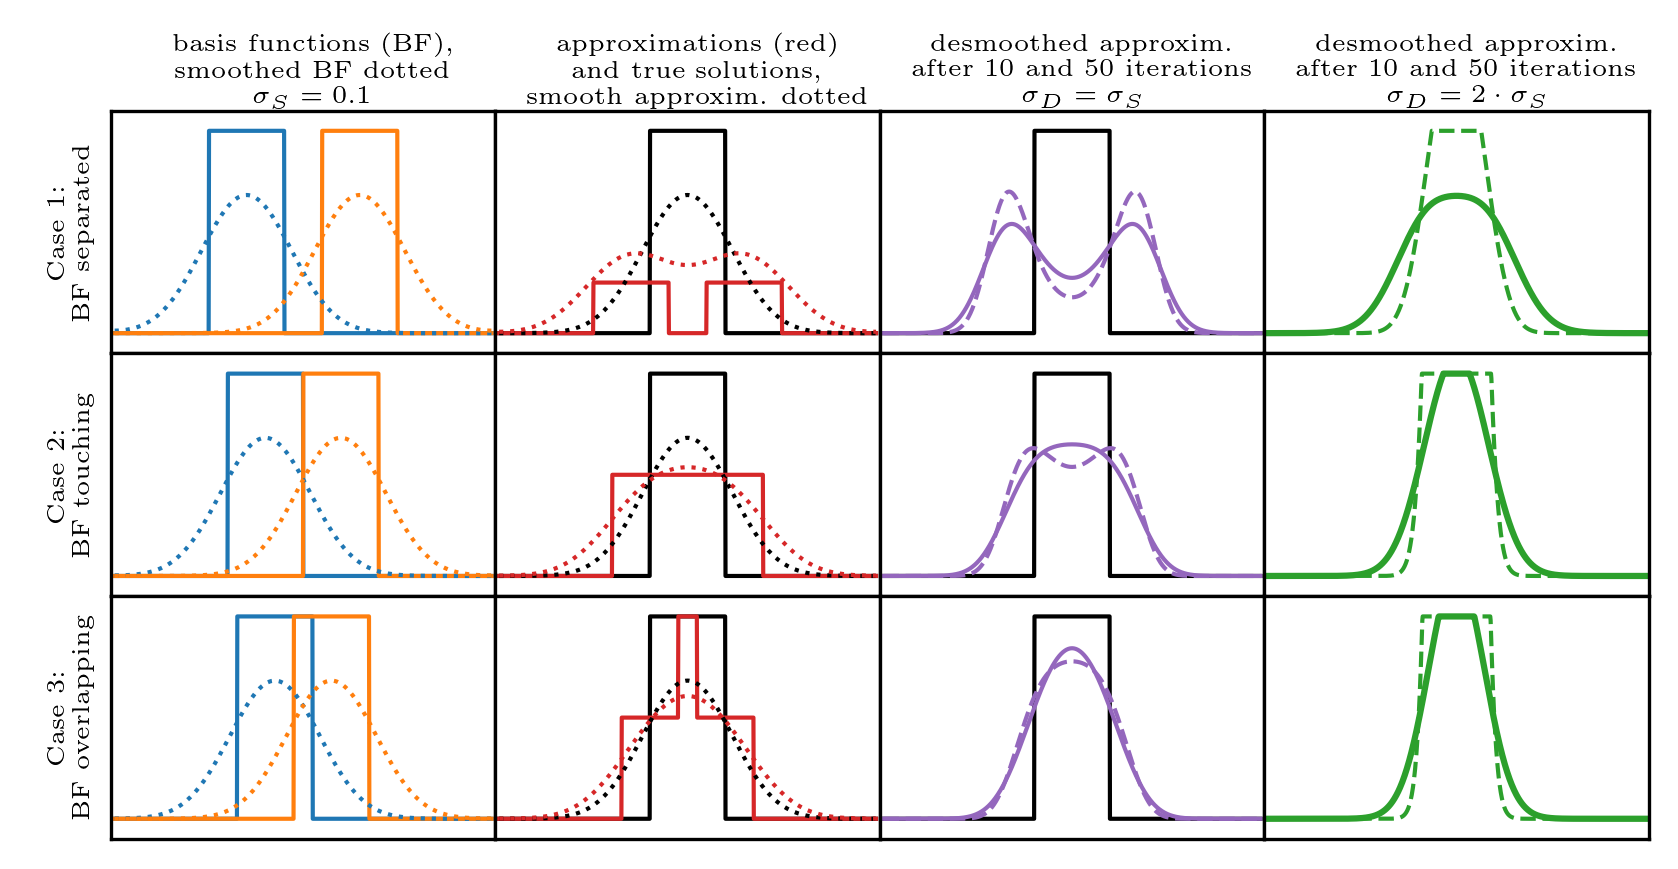

In [8]:
def new_small_figure():
    fig, ax = plt.subplots(1, 1, figsize=(page_width_in/4, page_width_in/4))
    ax.set_xticks(np.linspace(-1, 1, 21, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(-1, 1, 21, endpoint=True), minor=True)
    ax.set_yticklabels([])
    ax.grid(True, which='minor', linestyle='--', lw=.25)
    ax.grid(True, which='major', linestyle='-')
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.1, 1.1)
    return fig, ax


pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/"

fig, axs = small_figures()
for case, d, sig, color, row in zip(["separated", "touching", "overlapping"], [0.15, 0.1, 0.075], 
                                       [0.15, 0.1, 0.05], ["C1-", "C2--", "C3:"], [0, 1, 2]):
    N1 = f1(x, 0.5-d, w=0.1)
    N2 = f1(x, 0.5+d, w=0.1)
    N3 = f1(x, 0.5, w=0.1)
    A = np.vstack([N1, N2]).T
    N3_hat = approximate(A, N3)
    sig = 0.1
    N1_s = f3(x, 0.5-d, w=0.1, s=sig)
    N2_s = f3(x, 0.5+d, w=0.1, s=sig)
    N3_s = f3(x, 0.5, w=0.1, s=sig)
    A = np.vstack([N1_s, N2_s]).T
    N3_s_hat = approximate(A, N3_s)
    N3_D30_ = richardson_lucy(x, N3_s_hat, sgm=sig, num_iter=10, truth=None, damping=10, clip=True, mode="wrap")
    N3_D100_ = richardson_lucy(x, N3_s_hat, sgm=sig, num_iter=50, truth=None, damping=10, clip=True, mode="wrap")
    N3_D30 = richardson_lucy(x, N3_s_hat, sgm=sig*2, num_iter=10, truth=None, damping=10, clip=True, mode="wrap")
    N3_D100 = richardson_lucy(x, N3_s_hat, sgm=sig*2, num_iter=50, truth=None, damping=10, clip=True, mode="wrap")

    for N3_hat_xy in [N3_hat, N3_s_hat, N3_D30_, N3_D100_, N3_D30, N3_D100]:
        e = np.mean((N3_hat_xy-N3)**2)**.5
        print("{:.3f}".format(e), end=" &")
    print("\\\\")

    axs[row, 0].plot(x, N1, "C0", lw=1, label="$N_1$")
    axs[row, 0].plot(x, N2, "C1", lw=1, label="$N_2$")
    axs[row, 0].plot(x, N1_s, "C0:", lw=1, label="$N_{1,S}$")
    axs[row, 0].plot(x, N2_s, "C1:", lw=1, label="$N_{2,S}$")

    axs[row, 1].plot(x, N3, "k-", lw=1, label="$N_3$")
    axs[row, 1].plot(x, N3_hat, "C3-", lw=1, label="$\widehat{N}_3$")
    axs[row, 1].plot(x, N3_s, "k:", lw=1, label="$N_{3,S}$")
    axs[row, 1].plot(x, N3_s_hat, "C3:", lw=1, label="$\widehat{N}_{3,S}$")
    
    axs[row, 2].plot(x, N3, "k-", lw=1, label="$N_3$")
    axs[row, 2].plot(x, N3_D30_, "C4-", lw=1, label="$\widehat{N}_{3,D_{30}}$")
    axs[row, 2].plot(x, N3_D100_, "C4--", lw=1, label="$\widehat{N}_{3,D_{100}}$")
    
    axs[row, 3].plot(x, N3_D30, "C2-", label="$\widehat{N}_{3,D_{30}}$")
    axs[row, 3].plot(x, N3_D100, "C2--", lw=1, label="$\widehat{N}_{3,D_{100}}$")
plt.savefig(pth+"example1.pdf")
plt.show()
    


In [9]:
n_ds = 100
distances = np.linspace(0, 0.15, n_ds)
sigmas = [0.01, 0.02, 0.05]
n_sigmas = len(sigmas)
e1 = np.zeros(n_ds,)
e2 = np.zeros((n_ds, n_sigmas),)
e3 = np.zeros((n_ds, n_sigmas),)
e4 = np.zeros((n_ds, n_sigmas),)
e5 = np.zeros((n_ds, n_sigmas),)
for i, d in enumerate(distances):
    print(i, end=", ")
    N1 = f1(x, 0.5-d, w=0.1)
    N2 = f1(x, 0.5+d, w=0.1)
    N3 = f1(x, 0.5, w=0.1)
    A = np.vstack([N1, N2]).T
    N3_hat = approximate(A, N3)
    e1[i] = np.mean((N3_hat-N3)**2)**.5
    for j, sig in enumerate(sigmas):
        N1_s = f3(x, 0.5-d, w=0.1, s=sig)
        N2_s = f3(x, 0.5+d, w=0.1, s=sig)
        N3_s = f3(x, 0.5, w=0.1, s=sig)
        A = np.vstack([N1_s, N2_s]).T
        N3_s_hat = approximate(A, N3_s)
#         N3_D30_ = richardson_lucy(x, N3_s_hat, sgm=sig, num_iter=10, truth=None, damping=10, clip=True, mode="wrap")
#         N3_D100_ = richardson_lucy(x, N3_s_hat, sgm=sig, num_iter=50, truth=None, damping=10, clip=True, mode="wrap")
#         N3_D30 = richardson_lucy(x, N3_s_hat, sgm=sig*2, num_iter=10, truth=None, damping=10, clip=True, mode="wrap")
        N3_D100 = richardson_lucy(x, N3_s_hat, sgm=sig*2, num_iter=50, truth=None, damping=10, clip=True, mode="wrap")
#         e2[i, j] = np.mean((N3_s_hat-N3)**2)**.5
        e3[i, j] = np.mean((N3_s_hat-N3_s)**2)**.5
#         e4[i, j] = np.mean((N3_D30-N3)**2)**.5
        e5[i, j] = np.mean((N3_D100-N3)**2)**.5


0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 

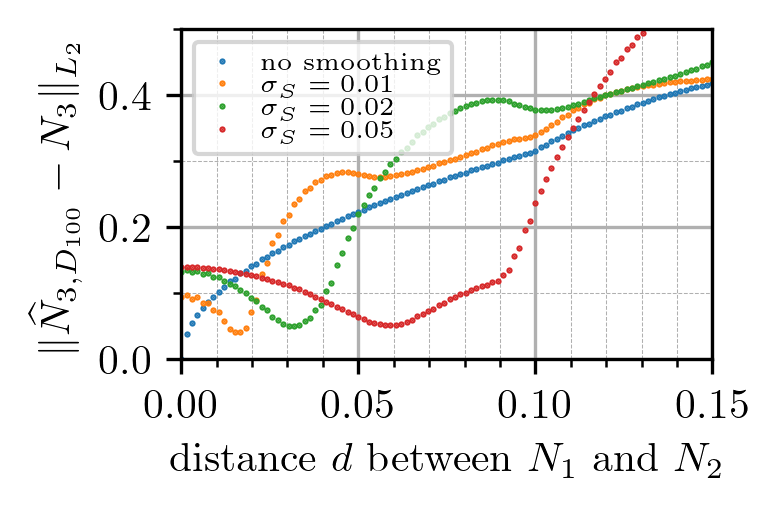

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(page_width_in/2, page_width_in/3))

ax.plot(distances, e1, "C0.", ms=1, label="no smoothing")
ax.plot(distances, e5[:, 0], "C1.", ms=1, label="$\sigma_S=0.01$")
ax.plot(distances, e5[:, 1], "C2.", ms=1, label="$\sigma_S=0.02$")
ax.plot(distances, e5[:, 2], "C3.", ms=1, label="$\sigma_S=0.05$")

ax.set_xticks(np.linspace(0, .15, 16, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
#ax.set_yticklabels([])
ax.legend()
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')

plt.xlabel("distance $d$ between $N_1$ and $N_2$")
plt.ylabel("$\|\widehat{N}_{3,D_{100}}-N_3\|_{L_2}$")
plt.xlim(0, 0.15)
plt.ylim(0, 0.5)
plt.savefig(pth+"example1_e_vs_d.pdf")
plt.show()

In [11]:
m = 250
x = np.linspace(0, 1, m)

ns = 100
n_trials = 5
X_tst1 = np.empty((m, ns))
X_tst2 = np.empty((m, ns))
mus = np.linspace(0, 1, ns, endpoint=False)+1/(2*ns)
for j, mu in enumerate(mus):
    X_tst1[:, j] = f1(x, mu, w=0.01)
    X_tst2[:, j] = f3(x, mu, w=0.01, s=0.015)
e0_1 = np.mean(np.mean((X_tst1)**2, axis=0)**.5)
e0_2 = np.mean(np.mean((X_tst2)**2, axis=0)**.5)

NN = np.arange(1, 100, 1)
e1 = np.zeros((len(NN), n_trials))
e2 = np.zeros((len(NN), n_trials))
e3 = np.zeros((len(NN), n_trials))-1

for i, n in enumerate(NN):
    for trial in range(n_trials):
        basis1 = np.empty((m, n))
        basis2 = np.empty((m, n))
        mu_rnd = np.random.rand(n,)
        for j, mu_j in enumerate(mu_rnd):
            basis1[:, j] = f1(x, mu_j, w=0.01)
            basis2[:, j] = f3(x, mu_j, w=0.01, s=0.015)
        
        coefficients1 = np.zeros((n, ns))
        coefficients2 = np.zeros((n, ns))

        for j, mu in enumerate(mus):
            coefficients1[:, j], _, _, _ = np.linalg.lstsq(basis1, X_tst1[:, j], rcond=None)
            coefficients2[:, j], _, _, _ = np.linalg.lstsq(basis2, X_tst2[:, j], rcond=None)
        approximations1 = basis1 @ coefficients1
        approximations2 = basis2 @ coefficients2
        #if trial==0 and i%2 == 0:
        approximations3 = post_process(x, approximations2, 0.015, c=2, mu_test=mus[:, None],
                                       mu_train=mu_rnd[:, None], num_iter=100,
                                       shape=(m,), clip=True, progress=False)
        e3[i, trial] = np.mean(np.mean((approximations3-X_tst1)**2, axis=0)**.5)
        #print(e3[i], e3[i]/e0_1)
        e1[i, trial] = np.mean(np.mean((approximations1-X_tst1)**2, axis=0)**.5)
        e2[i, trial] = np.mean(np.mean((approximations2-X_tst2)**2, axis=0)**.5)
#         for k in range(ns):
#             fig, ax = plt.subplots()
#             ax.plot(x, X_tst1[:, k])
#             ax.plot(x, X_tst2[:, k])
#             ax.plot(x, approximations1[:, k])
#             ax.plot(x, approximations2[:, k])
#             ax.plot(x, approximations3[:, k])
#             plt.show()
    print(n, np.median(e1[i, :])/e0_1, np.median(e2[i, :])/e0_2,  np.median(e3[i, :])/e0_1)


1 0.9871107210947111 0.9706432457820441 0.9971856521555463
2 0.9858665363437251 0.9441453107169118 1.0007397282653878
3 0.9702312765643045 0.9133591613929092 0.9989661069671602
4 0.964537535173233 0.8862359928394868 1.0009386818409163
5 0.9574708033450954 0.8584216256794431 0.9726022355015483
6 0.9401621572331433 0.8336974747410344 0.9607063516451098
7 0.9379776486046483 0.8158278454489815 0.9264789335200415
8 0.9258369043404842 0.7817384866546089 0.9005921199565885
9 0.9175355905968082 0.7681144305010325 0.8875288805420756
10 0.9174060244696345 0.7358353565541688 0.9052142024262224
11 0.9025629250974366 0.7029637795590185 0.8873411391142967
12 0.8994555492186765 0.6841013771041735 0.8405627562327332
13 0.8823046631199394 0.663063901488069 0.8516584580419213
14 0.8747735942625527 0.644603641499076 0.7958033436730333
15 0.8662083192233989 0.6350823120295734 0.7699666611275221
16 0.8533405165617244 0.6063067722109643 0.7412366951770528
17 0.8530254368960186 0.5890300062847893 0.734805741

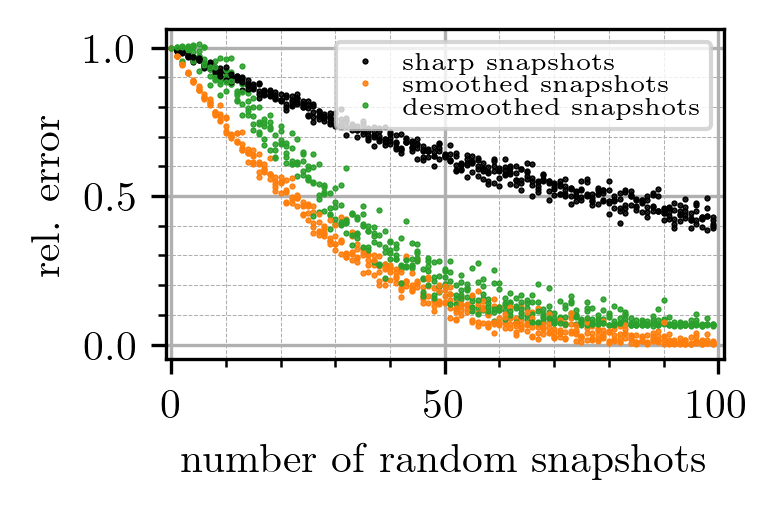

[98.88905438 98.52994631 97.15554935 96.2742991  95.94564801 93.93924474
 93.97473529 92.50983845 91.75313536 91.2435448  90.03686846 89.85343423
 88.33687191 87.47166141 86.7680507  85.69535453 84.96038566 84.51453657
 83.6136456  82.68247613 81.45659314 81.71535693 82.57487451 80.79088239
 79.32632764 78.29911018 77.45898976 76.46141973 76.13349384 75.1793495
 75.31001734 74.21876845 73.29928493 72.13883324 72.87204992 70.7510858
 70.38382663 70.53283594 69.37054692 69.57240525 67.73776664 66.53840285
 68.66775377 66.84501164 66.53916984 64.54559185 64.89652674 63.66426379
 65.84627404 63.61340558 63.49044875 61.11972575 60.05054229 60.87679993
 61.20289142 60.1804706  58.86001034 56.89935412 59.40903161 57.22312139
 59.02772082 57.81017303 56.39895935 56.02716363 58.01492454 55.10091353
 53.39235875 56.07819389 52.90193325 52.79869366 52.75609035 52.41383155
 51.038013   50.24794987 51.60752795 52.25797733 48.76122777 50.71099806
 50.39367008 49.42119369 48.40061249 46.42407345 48.0

In [12]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
ax.plot(0, e0_1/e0_1, "k.", ms=1, label="sharp snapshots")
ax.plot(0, e0_2/e0_2, "C1.", ms=1, label="smoothed snapshots")
ax.plot(0, e0_1/e0_1, "C2.", ms=1, label="desmoothed snapshots")

for trial in range(n_trials):
    ax.plot(NN, e1[:, trial]/e0_1, "k.", ms=1)
    ax.plot(NN, e2[:, trial]/e0_2, "C1.", ms=1)
    ax.plot(NN, e3[:, trial]/e0_1, "C2.", ms=1)
#    ax.plot(NN, e3[:, trial]/e0_1, "C2.", ms=1)
# ax.plot(np.r_[0, NN], np.r_[1, np.median(e1/e0_1, axis=-1)], "k--", lw=1)
# ax.plot(np.r_[0, NN], np.r_[1, np.median(e2/e0_2, axis=-1)], "C1--", lw=1)
# ax.plot(np.r_[0, NN], np.r_[1, np.median(e3/e0_1, axis=-1)], "C2--", lw=1)
#ax.plot(NN, np.mean(e3/e0_1, axis=-1), "C2--", ms=1)

ax.grid()
#ax.set_yscale('log')
ax.set_xticks(np.linspace(0, 200, 21, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
ax.set_xlim([-1, 101])
#ax.set_ylim([0, 1.])
ax.set_xlabel("number of random snapshots")
ax.set_ylabel("rel. error")
plt.legend()

plt.savefig(pth+"1st_ex_decay_v2.pdf")
plt.show()
np.set_printoptions(suppress=True)
print(np.mean(e1/e0_1, axis=-1)*100)
print(np.mean(e2/e0_2, axis=-1)*100)


In [13]:
asd

NameError: name 'asd' is not defined

In [ ]:
for j, mu in enumerate(mus):
    if j%15 == 0:
        plt.plot(x, X_tst1[:, j])
        plt.plot(x, X_tst2[:, j], ls="--")

In [ ]:
np.logspace(-6, 1, 5, endpoint=True)

In [ ]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
ax.plot(0, e0_1/e0_1, "k.", ms=1)
ax.plot(0, e0_2/e0_2, "C1.", ms=1)

for trial in range(n_trials):
    ax.plot(NN, e1[:, trial]/e0_1, "k.", ms=1)
    ax.plot(NN, e2[:, trial]/e0_2, "C1.", ms=1)
#    ax.plot(NN, e3[:, trial]/e0_1, "C2.", ms=1)
ax.plot(np.r_[0, NN], np.r_[1, np.median(e1/e0_1, axis=-1)], "k--", ms=1)
ax.plot(np.r_[0, NN], np.r_[1, np.median(e2/e0_2, axis=-1)], "C1--", ms=1)
#ax.plot(NN, np.mean(e3/e0_1, axis=-1), "C2--", ms=1)

ax.grid()
ax.set_xlim([-5, 205])
ax.set_ylim([1e-6, 2])
ax.set_yscale('log')
ax.set_xticks(np.linspace(0, 200, 21, endpoint=True), minor=True)
ax.set_yticks(np.logspace(-6, 0, 7, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.show()
np.set_printoptions(suppress=True)
print(np.mean(e1/e0_1, axis=-1)*100)
print(np.mean(e2/e0_2, axis=-1)*100)

In [ ]:
asd

In [ ]:
approximations *= 0
e = np.mean((X_tst)**2, axis=0)**.5
print(e)
print(n, np.mean(e))

In [ ]:
asd

In [ ]:
def pulse(x, mu, w=0.1+1e-6):
    y = np.zeros_like(x, dtype=np.float64)
    y[((0+1e-6) < (x-mu)) & ((x-mu) < (w-1e-6))] = 1.0
    mu2 = mu+1
    y[((0+1e-6) < (x-mu2)) & ((x-mu2) < (w-1e-6))] = -1.0
    mu3 = mu-1
    y[((0+1e-6) < (x-mu3)) & ((x-mu3) < (w-1e-6))] = -1.0
    mu4 = mu-2
    y[((0+1e-6) < (x-mu4)) & ((x-mu4) < (w-1e-6))] = 1.0
    return y

from smooth_POD_ROM.pre_processing import smoothen

In [ ]:
fig, axg1 = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
fig, axs1 = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
fig, axg2 = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
fig, axs2 = plt.subplots(figsize=(page_width_in/2, page_width_in/3))

for n in [10, 20, 30, 1000]:
    x = np.linspace(-1, 2, 3*m, endpoint=False) + 1/2*(1/m)
    mu = np.linspace(0, 2, n, endpoint=False) #+ 1/2*(2/n)
    print(x[0], x[-1])
    print(x[0]-(-1), 2-x[-1])
    print("mu")
    print(mu[0], mu[-1])
    print(mu[0], 2-mu[-1])
    print(n)
    
    X = np.empty((3*m, n))
    for j, mu_j in enumerate(mu):
        y = pulse(x, mu_j)
        X[:, j] = y

    dx = 1/m
    Xs = smoothen(X, sigma=0.1/dx, shape=(3*m,), truncate=8, mode="wrap")
    X = X[m:-m]
    Xs = Xs[m:-m]
    x = x[m:-m]
    Ug, Sg, Vg = np.linalg.svd(X, full_matrices=False)
    Us, Ss, Vs = np.linalg.svd(Xs, full_matrices=False)

    fig, ax = plt.subplots()
    ax.plot(x, X[:, 0], "o-")
    ax.plot(x, X[:, 1], "o-")
    ax.plot(x, X[:, -1], "o-")
    #ax.set_xlim([.04, .06])
    
    Ug[:, np.mean(Ug, axis=0)<0] *= -1
    Us[:, np.mean(Us, axis=0)<0] *= -1
    if np.mean(Ug[:, 0])>np.mean(Ug[:, 1]):
        tmp = Ug[:, 0].copy()
        Ug[:, 0] = Ug[:, 1].copy()
        Ug[:, 1] = tmp.copy()
    if np.mean(Us[:, 0])>np.mean(Us[:, 1]):
        tmp = Us[:, 0].copy()
        Us[:, 0] = Us[:, 1].copy()
        Us[:, 1] = tmp.copy()
    axg1.plot(x, Ug[:, 0], ".-", ms=1, label="$n_{\mu}=%i$"%n)
    axs1.plot(x, Us[:, 0], ".-", ms=1, label="$n_{\mu}=%i$"%n)
    axg2.plot(x, Ug[:, 1], ".-", ms=1, label="$n_{\mu}=%i$"%n)
    axs2.plot(x, Us[:, 1], ".-", ms=1, label="$n_{\mu}=%i$"%n)
for ax in [axg1, axs1, axg2, axs2]:
    ax.set_xticks(np.linspace(-1., 1., 21, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(-.2, .2, 21, endpoint=True), minor=True)
    ax.grid(True, which='minor', linestyle='--', lw=.25)
    ax.grid(True, which='major', linestyle='-')
    ax.legend()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.15, 0.15)
#axs1.set_ylim(-0.15, 0.15)
plt.show()